In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

In [2]:
df = pd.read_csv("interactions.csv")  # columns: user_id, movie_id

print("Num users:", df['user_id'].nunique())
print("Num items:", df['item_id'].nunique())
print("Num interactions:", len(df))

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

Num users: 942
Num items: 1447
Num interactions: 55375


#### UNS

In [3]:
def sample_negatives(df, num_neg=4):
    # TODO:
    # 1. Create a set of (user, item) interactions
    observed = set(zip(df['user_id'], df['item_id']))
    all_items = df['item_id'].unique()

    rows = []
    # 2. For each positive interaction:
    #    - add (user, item, 1)
    #    - sample 'num_neg' negative items
    for i in range(len(df)):
        user = df['user_id'].iloc[i]
        item = df['item_id'].iloc[i]
        
        rows.append((user, item, 1))
        
        sampled = 0
        while sampled < num_neg:
            neg_item = np.random.choice(all_items)
            if (user, neg_item) not in observed:
                rows.append((user, neg_item, 0))
                sampled += 1

    # 3. Return a dataframe with columns: user, item, label
    return pd.DataFrame(rows, columns=['user', 'item', 'label'])

In [4]:
class InteractionDataset(TensorDataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user'].values)
        self.items = torch.tensor(df['item'].values)
        self.labels = torch.tensor(df['label'].values).float()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]
    
train_data = sample_negatives(train_df)

train_loader = DataLoader(InteractionDataset(train_data), batch_size=256, shuffle=True)

dataset = TensorDataset(
    torch.tensor(train_data['user'].values),
    torch.tensor(train_data['item'].values),
    torch.tensor(train_data['label'].values)
)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [5]:
# Interactions per user
user_counts = df['user_id'].value_counts()
print(user_counts.describe())

# Interactions per item
item_counts = df['item_id'].value_counts()
print(item_counts.describe())

count    942.000000
mean      58.784501
std       54.696664
min        3.000000
25%       19.000000
50%       39.500000
75%       80.750000
max      378.000000
Name: count, dtype: float64
count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
Name: count, dtype: float64


#### MF

In [6]:
class MF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        # TODO:
        # - Define user embedding layer
        self.user_embedding = nn.Embedding(num_users, emb_dim) # acts as a learnable lookup table with num_users rows, emb_dim columns
        # - Define item embedding layer
        self.item_embedding = nn.Embedding(num_items, emb_dim)

    def forward(self, user, item):
        # TODO:
        # - Get user and item embeddings
        user_vec = self.user_embedding(user) # give me row 'user' of the matrix
        item_vec = self.item_embedding(item) # give me row 'item' of the matrix
        # - Compute dot product
        dot = (user_vec * item_vec).sum(dim=1) # we can't use torch.dot() because that is for 1D tensors
        # - Return a single score per pair
        return torch.sigmoid(dot)

#### MLP

In [7]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()

        # TODO:
        # - Define user embedding layer
        self.user_embedding = nn.Embedding(num_users, emb_dim)
        # - Define item embedding layer
        self.item_embedding = nn.Embedding(num_items, emb_dim)
        # - Define MLP layers
        self.l1 = nn.Linear(emb_dim * 2, 64)
        self.l2 = nn.Linear(64, 32)
        self.l3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, user, item):
        # TODO:
        # - Get embeddings
        user_vec = self.user_embedding(user)
        item_vec = self.item_embedding(item)
        # - Concatenate user and item embeddings
        x = torch.cat((user_vec, item_vec), dim=1)
        # - Pass through MLP
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = torch.sigmoid(self.l3(x))
        # - Return a single score
        return x.squeeze() # removes extra dimension

#### GMF

In [8]:
class GMF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, emb_dim)
        self.item_embedding = nn.Embedding(num_items, emb_dim)
        self.h = nn.Linear(emb_dim, 1, bias=False) # this is h

    def forward(self, user, item):
        p_u = self.user_embedding(user)
        q_i = self.item_embedding(item)
        phi = p_u * q_i # element-wise product
        out = self.h(phi) # h^T phi
        return torch.sigmoid(out).squeeze()

#### NeuMF

In [9]:
class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim):
        super().__init__()
        self.gmf = GMF(num_users, num_items, emb_dim)
        self.mlp = MLP(num_users, num_items, emb_dim)

        self.final = nn.Linear(emb_dim + 32, 1) 

    def forward(self, user, item):
        p_u_gmf = self.gmf.user_embedding(user)
        q_i_gmf = self.gmf.item_embedding(item)

        p_u_mlp = self.mlp.user_embedding(user)
        q_i_mlp = self.mlp.item_embedding(item)

        phi_gmf = p_u_gmf * q_i_gmf
        phi_mlp = torch.cat((p_u_mlp, q_i_mlp), dim=1)
        phi_mlp = self.mlp.relu(self.mlp.l1(phi_mlp))
        phi_mlp = self.mlp.relu(self.mlp.l2(phi_mlp))
        

        final_inp = torch.cat((phi_gmf, phi_mlp), dim=1)
        final = self.final(final_inp)
        final = torch.sigmoid(final)

        return final.squeeze()

#### Hit@K

In [10]:
def hit_at_k(model, test_df, full_df, K=10, num_neg=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    hits = 0
    total = len(df) # We evaluate every positive interaction in the test set

    # Map interactions for quick lookup
    interacted_items = full_df.groupby('user_id')['item_id'].apply(set).to_dict()
    all_items = full_df['item_id'].unique()

    with torch.no_grad(): # Disable gradient calculation for speed/memory
        for _, row in df.iterrows():
            u = int(row['user_id'])
            pos_item = int(row['item_id'])

            # 1. Sample Negatives
            negatives = []
            while len(negatives) < num_neg:
                neg_item = np.random.choice(all_items)
                if neg_item not in interacted_items.get(u, set()):
                    negatives.append(neg_item)

            # 2. Prepare Tensors
            # We need a list of the 1 positive + 100 negatives
            item_list = [pos_item] + negatives
            user_tensor = torch.tensor([u] * (num_neg + 1)).to(device)
            item_tensor = torch.tensor(item_list).to(device)

            # 3. Get Scores
            scores = model(user_tensor, item_tensor)

            # 4. Rank and Check Hit
            # We want to see if the item at index 0 (the positive) is in the top K
            # torch.topk returns values and indices of the highest scores
            _, top_indices = torch.topk(scores, K)

            top_indices = top_indices.cpu().numpy()
            if 0 in top_indices:
                hits += 1

    return hits / total

#### Training functions

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_one_epoch(model, dataloader, optimizer):
    model.to(device)
    model.train()
    total_loss = 0
    lossfn = nn.BCELoss()

    for user, item, label in dataloader:
        user, item, label = user.to(device), item.to(device), label.float().to(device)

        optimizer.zero_grad()
        pred = model(user, item)
        loss = lossfn(pred, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss

In [12]:
def evaluate(model, test_df, full_df):
    model.eval()
    with torch.no_grad():
        return hit_at_k(model, test_df, full_df)

In [13]:
def train_and_evaluate(model, dataloader, test_df, full_df, epochs, eval_every=5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    lossfn = nn.BCELoss()

    losses, scores, eval_epochs = [], [], []

    for epoch in range(epochs):
        loss = train_one_epoch(model, dataloader, optimizer)
        losses.append(loss)

        if (epoch + 1) % eval_every == 0:
            score = evaluate(model, test_df, full_df)
            scores.append(score)
            eval_epochs.append(epoch + 1)
            print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Hit@10: {score:.4f}")
        else:
            print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

    return losses, scores, eval_epochs

In [14]:
num_users = df['user_id'].nunique()
num_items = df['item_id'].nunique()

#### Individual model training

In [15]:
# MF
mf_model = MF(num_users, num_items, emb_dim=32)
mf_losses, mf_scores, mf_epochs = train_and_evaluate(
    mf_model, dataloader, test_df, df, epochs=25, eval_every=5
)
print("-" * 30)
# MLP
mlp_model = MLP(num_users, num_items, emb_dim=32)
mlp_losses, mlp_scores, mlp_epochs = train_and_evaluate(
    mlp_model, dataloader, test_df, df, epochs=25, eval_every=5
)
print("-" * 30)
# NeuMF
neumf_model = NeuMF(num_users, num_items, emb_dim=32)
neumf_losses, neumf_scores, neumf_epochs = train_and_evaluate(
    neumf_model, dataloader, test_df, df, epochs=25, eval_every=5
)

c:\Python 3.13\Lib\site-packages\torch\cuda\__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5070 Ti Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5070 Ti Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Epoch 1, Loss: 2061.6381
Epoch 2, Loss: 1772.1889
Epoch 3, Loss: 1546.5409
Epoch 4, Loss: 1357.6174
Epoch 5, Loss: 1189.6974, Hit@10: 0.1051
Epoch 6, Loss: 1041.9102
Epoch 7, Loss: 905.4116


KeyboardInterrupt: 

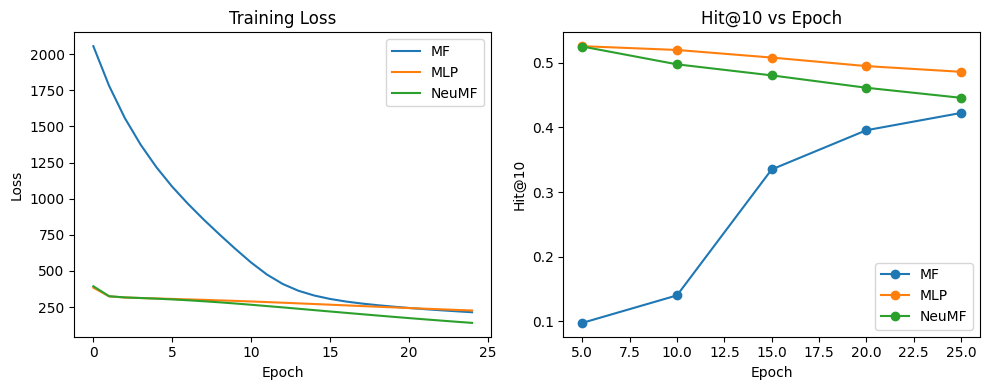

In [50]:
plt.figure(figsize=(10, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(mf_losses, label='MF')
plt.plot(mlp_losses, label='MLP')
plt.plot(neumf_losses, label='NeuMF')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()


# Hit@10 plot
plt.subplot(1, 2, 2)
plt.plot(mf_epochs, mf_scores, label='MF', marker='o')
plt.plot(mlp_epochs, mlp_scores, label='MLP', marker='o')
plt.plot(neumf_epochs, neumf_scores, label='NeuMF', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Hit@10')
plt.title('Hit@10 vs Epoch')
plt.legend()


plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

#### PNS


In [16]:
def pns(df, train_df, num_neg=4):
    item_counts = df['item_id'].value_counts().sort_index()
    weights = item_counts.to_dict()

    all_items = df['item_id'].unique()

    interacted = df.groupby('user_id')['item_id'].apply(set).to_dict()

    users, items_list, labels = [], [], []

    for _, row in train_df.iterrows():
        u = int(row['user_id'])
        i = int(row['item_id'])

        # positive sample
        users.append(u)
        items_list.append(i)
        labels.append(1)

        # WRS (weighted random sampling) negative sampling
        candidates = []
        user_items = interacted.get(u, set()) # u is the user id

        for item in all_items: # run through all the items
            if item in user_items: # if user has interacted with that item, then continue
                continue

            w = weights.get(item, 1.0) # if not, then we add it to the potential candidates to sample
            if w <= 0:
                w = 1e-6

            u_rand = np.random.rand()
            key = u_rand ** (1.0 / w)

            candidates.append((key, item))

        candidates.sort(reverse=True)
        negs = [item for _, item in candidates[:num_neg]]

        for j in negs:
            users.append(u)
            items_list.append(j)
            labels.append(0)

    return {
        'user': np.array(users),
        'item': np.array(items_list),
        'label': np.array(labels)
    }

#### Combined model training

NOTE: ```train_and_evaluate``` was used to train one model at a time. But from now on, we are interested in training them together for efficiency. So we will continue using the ```train()``` and ```evaluate()``` functions seperately as needed.

In [ ]:
emb_dims = [8, 16, 32, 64]
epochs = 25
eval_every = 5

results = {
    'Uniform': {'MF': [], 'MLP': [], 'NeuMF': []},
    'Weighted': {'MF': [], 'MLP': [], 'NeuMF': []}
}

losses = {
    'Uniform': {'MF': [], 'MLP': [], 'NeuMF': []},
    'Weighted': {'MF': [], 'MLP': [], 'NeuMF': []}
}

scores_epoch = {
    'Uniform': {'MF': [], 'MLP': [], 'NeuMF': []},
    'Weighted': {'MF': [], 'MLP': [], 'NeuMF': []}
}

for emb_dim in emb_dims:
    print(f"\n{'='*50}")
    print(f"Embedding Dimension = {emb_dim}")
    print(f"{'='*50}")

    for mode in ['Uniform', 'Weighted']:
        print(f"\n[{mode} Sampling]")

        if mode == 'Uniform':
            train_data = sample_negatives(train_df, num_neg=4)
        else:
            train_data = pns(train_df, df, num_neg=4)

        dataset = TensorDataset(
            torch.tensor(train_data['user'].values, dtype=torch.long),
            torch.tensor(train_data['item'].values, dtype=torch.long),
            torch.tensor(train_data['label'].values, dtype=torch.float)
        )
        dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

        # initializing all 3 models and optimizers
        models = {
            'MF': MF(num_users, num_items, emb_dim).to(device),
            'MLP': MLP(num_users, num_items, emb_dim).to(device),
            'NeuMF': NeuMF(num_users, num_items, emb_dim).to(device)
        }
        optimizers = {
            name: torch.optim.Adam(model.parameters(), lr=0.001)
            for name, model in models.items()
        }

        # storage per model
        loss_lists = {name: [] for name in models}
        score_lists = {name: [] for name in models}

        for epoch in range(epochs):
            # train all 3 for one epoch
            for name, model in models.items():
                loss = train_one_epoch(model, dataloader, optimizers[name])
                loss_lists[name].append(loss)

            # evaluate all 3 together and print one line
            if (epoch + 1) % eval_every == 0:
                scores = {
                    name: evaluate(model, test_df, df)
                    for name, model in models.items()
                }
                for name, score in scores.items():
                    score_lists[name].append(score)

                print(f"Epoch {epoch+1:2d} | "
                      f"MF: {scores['MF']:.4f} | "
                      f"MLP: {scores['MLP']:.4f} | "
                      f"NeuMF: {scores['NeuMF']:.4f}")

        # store results
        for name in models:
            losses[mode][name].append(loss_lists[name])
            scores_epoch[mode][name].append(score_lists[name])
            results[mode][name].append(score_lists[name][-1])


Embedding Dim = 8

[Uniform Sampling]
Epoch  5 | MF: 0.0895 | MLP: 0.5302 | NeuMF: 0.5355
Epoch 10 | MF: 0.1671 | MLP: 0.5330 | NeuMF: 0.5409


KeyboardInterrupt: 

#### Data Visualization

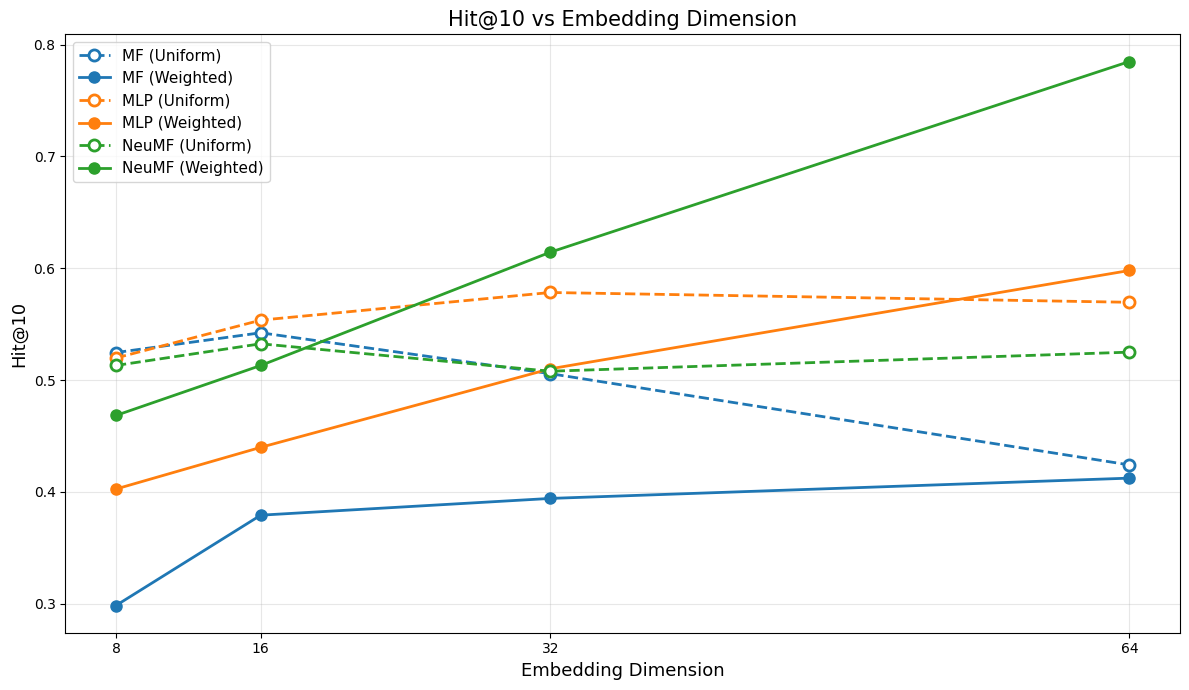

In [ ]:
colors = {
    'MF':'#1f77b4', # blue
    'MLP':'#ff7f0e', # orange
    'NeuMF':'#2ca02c' # green
}

plt.figure(figsize=(12, 7))

for model in ['MF', 'MLP', 'NeuMF']:

    plt.plot(
        emb_dims,
        results['Uniform'][model],
        linestyle='--',
        marker='o',
        markersize=8,
        linewidth=2,
        color=colors[model],
        markerfacecolor='white',
        markeredgewidth=2,
        label=f'{model} (Uniform)'
    )

    plt.plot(
        emb_dims,
        results['Weighted'][model],
        linestyle='-',
        marker='o',
        markersize=8,
        linewidth=2,
        color=colors[model],
        label=f'{model} (Weighted)'
    )

plt.xlabel("Embedding Dimension", fontsize=13)
plt.ylabel("Hit@10", fontsize=13)
plt.title("Hit@10 vs Embedding Dimension", fontsize=15)

plt.xticks(emb_dims)
plt.grid(True, alpha=0.3)

plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

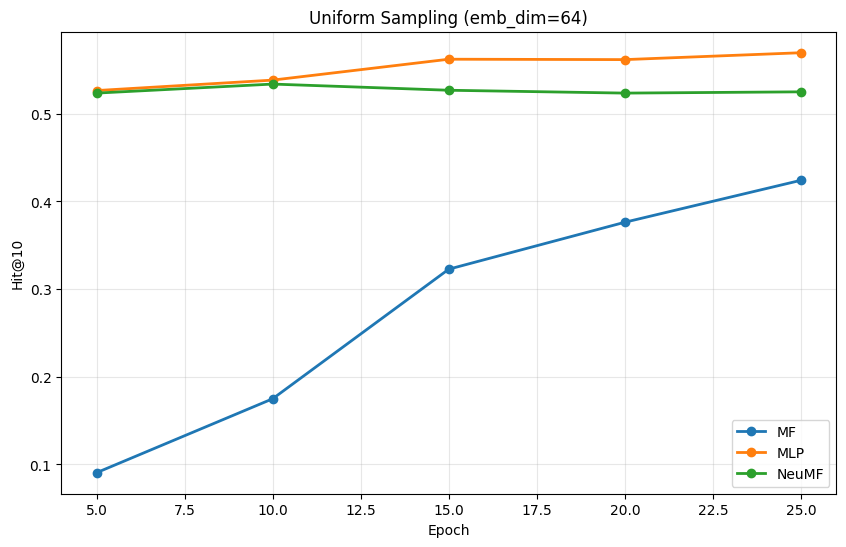

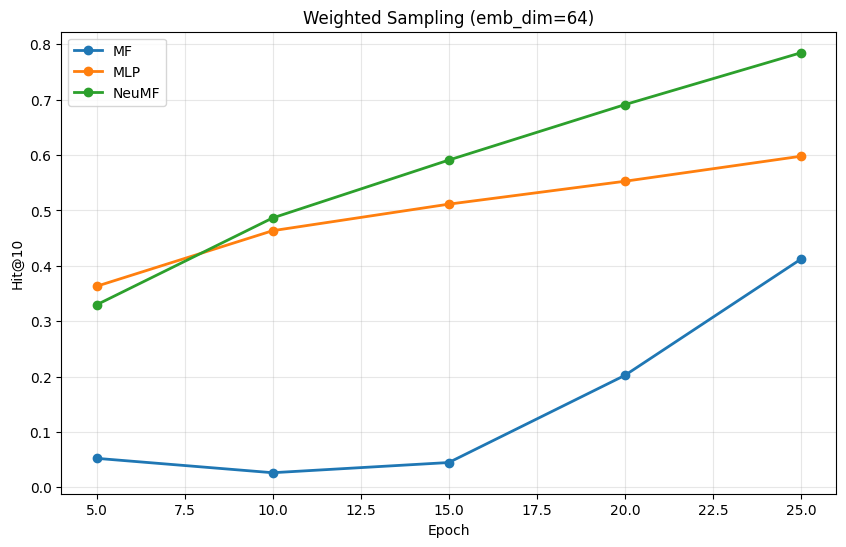

In [ ]:
emb_idx = 3   # 0->8, 1->16, 2->32, 3->64, we are looking at emb_dim = 64, since it has the most fascinating data! that neumf explodes!
x_axis = list(range(eval_every, epochs + 1, eval_every))

plt.figure(figsize=(10, 6))

for model in ['MF', 'MLP', 'NeuMF']:
    plt.plot(
        x_axis,
        scores_epoch['Uniform'][model][emb_idx],
        marker='o',
        linewidth=2,
        label=model
    )

plt.xlabel("Epoch")
plt.ylabel("Hit@10")
plt.title(f"Uniform Sampling (emb_dim={emb_dims[emb_idx]})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for model in ['MF', 'MLP', 'NeuMF']:
    plt.plot(
        x_axis,
        scores_epoch['Weighted'][model][emb_idx],
        marker='o',
        linewidth=2,
        label=model
    )

plt.xlabel("Epoch")
plt.ylabel("Hit@10")
plt.title(f"Weighted Sampling (emb_dim={emb_dims[emb_idx]})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

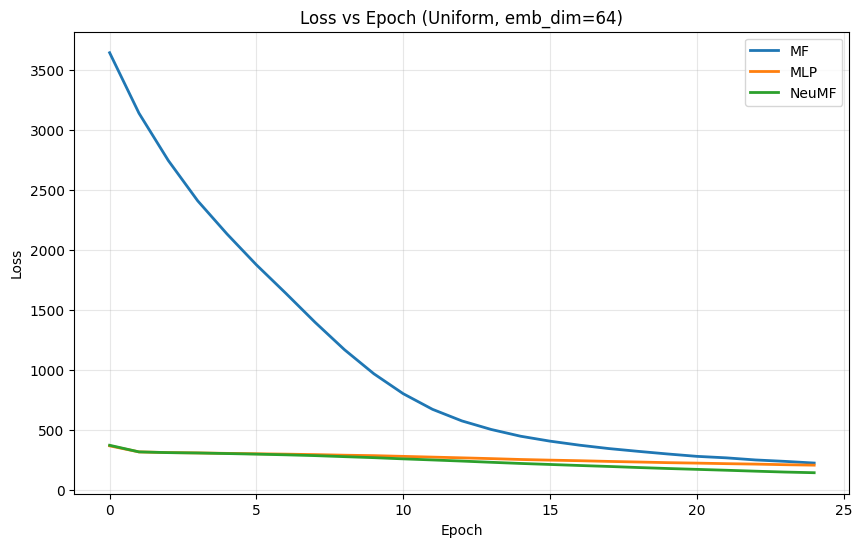

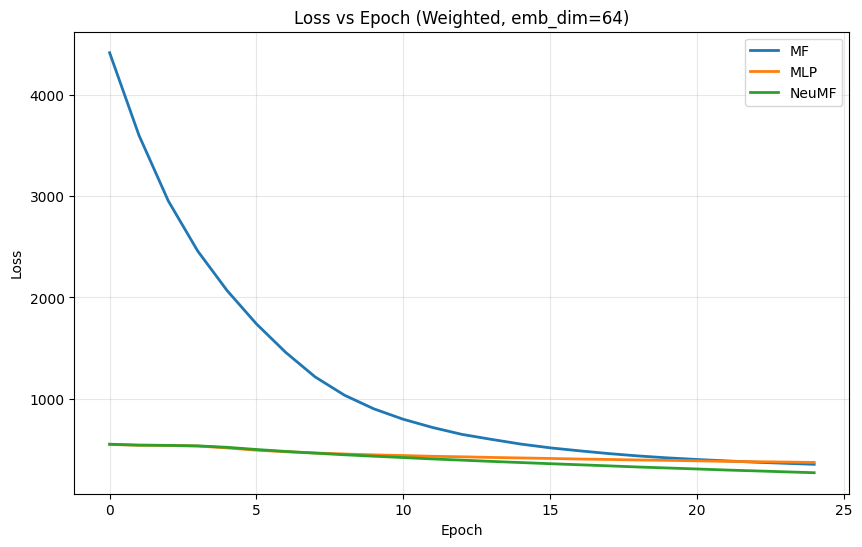

In [77]:
plt.figure(figsize=(10, 6))

for model in ['MF', 'MLP', 'NeuMF']:
    plt.plot(
        losses['Uniform'][model][emb_idx],
        linewidth=2,
        label=model
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss vs Epoch (Uniform, emb_dim={emb_dims[emb_idx]})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for model in ['MF', 'MLP', 'NeuMF']:
    plt.plot(
        losses['Weighted'][model][emb_idx],
        linewidth=2,
        label=model
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss vs Epoch (Weighted, emb_dim={emb_dims[emb_idx]})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### Data Extraction

In [87]:
rows = []

for mode in ['Uniform', 'Weighted']:
    for model in ['MF', 'MLP', 'NeuMF']:
        for emb_dim, score in zip(emb_dims, results[mode][model]):

            rows.append({
                'sampling': mode,
                'model': model,
                'embedding_dim': emb_dim,
                'hit@10': score
            })

results_df = pd.DataFrame(rows)

results_df.to_csv("final_results.csv", index=False)

print(results_df)

    sampling  model  embedding_dim    hit@10
0    Uniform     MF              8  0.524605
1    Uniform     MF             16  0.542302
2    Uniform     MF             32  0.505734
3    Uniform     MF             64  0.424108
4    Uniform    MLP              8  0.519729
5    Uniform    MLP             16  0.553589
6    Uniform    MLP             32  0.578330
7    Uniform    MLP             64  0.569571
8    Uniform  NeuMF              8  0.513047
9    Uniform  NeuMF             16  0.532460
10   Uniform  NeuMF             32  0.507901
11   Uniform  NeuMF             64  0.524966
12  Weighted     MF              8  0.298330
13  Weighted     MF             16  0.379142
14  Weighted     MF             32  0.394131
15  Weighted     MF             64  0.412280
16  Weighted    MLP              8  0.402528
17  Weighted    MLP             16  0.439819
18  Weighted    MLP             32  0.510068
19  Weighted    MLP             64  0.598014
20  Weighted  NeuMF              8  0.468352
21  Weight